In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")

In [4]:
resume_df = pd.read_csv('../data/UpdatedResumeDataSet.csv')
jd_df = pd.read_csv('../data/job_descriptions.csv')

print("Resume dataset shape:", resume_df.shape)
print("JD dataset shape:", jd_df.shape)

print("\nResume columns:", resume_df.columns.tolist())
print("JD columns:", jd_df.columns.tolist())

Resume dataset shape: (962, 2)
JD dataset shape: (1615940, 23)

Resume columns: ['Category', 'Resume']
JD columns: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']


In [5]:
print("=== RESUME SAMPLE ===")
print(resume_df.head(3))
print("\nResume categories:")
print(resume_df['Category'].value_counts())

=== RESUME SAMPLE ===
       Category                                             Resume
0  Data Science  Skills * Programming Languages: Python (pandas...
1  Data Science  Education Details \r\nMay 2013 to May 2017 B.E...
2  Data Science  Areas of Interest Deep Learning, Control Syste...

Resume categories:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network S

In [6]:
jd_df = jd_df.sample(n=5000, random_state=42).reset_index(drop=True)

jd_df = jd_df[['Job Title', 'Job Description', 'skills', 'Role']]

print("JD sample shape:", jd_df.shape)
print("\n=== JD SAMPLE ===")
print(jd_df.head(3))
print("\nMissing values:")
print(jd_df.isnull().sum())

JD sample shape: (5000, 4)

=== JD SAMPLE ===
                Job Title                                    Job Description  \
0     Procurement Manager  Promote diversity and inclusion in the supply ...   
1  Architectural Designer  Architectural Drafters assist architects and e...   
2             Art Teacher  An Art Education Coordinator plans and manages...   

                                              skills  \
0  Supplier diversity programs Diversity and incl...   
1  Architectural drafting AutoCAD 2D and 3D model...   
2  Art education curriculum Program development T...   

                         Role  
0  Supplier Diversity Manager  
1       Architectural Drafter  
2   Art Education Coordinator  

Missing values:
Job Title          0
Job Description    0
skills             0
Role               0
dtype: int64


In [7]:
print("Resume missing values:")
print(resume_df.isnull().sum())

jd_df['full_jd'] = jd_df['Job Title'] + ' ' + jd_df['Job Description'] + ' ' + jd_df['skills']

print("\n=== SAMPLE RESUME TEXT (first 500 chars) ===")
print(resume_df['Resume'][0][:500])

print("\n=== SAMPLE JD TEXT (first 500 chars) ===")
print(jd_df['full_jd'][0][:500])

Resume missing values:
Category    0
Resume      0
dtype: int64

=== SAMPLE RESUME TEXT (first 500 chars) ===
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib

=== SAMPLE JD TEXT (first 500 chars) ===
Procurement Manager Promote diversity and inclusion in the supply chain, manage supplier diversity programs, and assess supplier performance. Supplier diversity programs Diversity and inclusion initiatives Supplier assessment and certification Data collection and reporting Vendor outreach and engagement Strategic planning Communication skills Re

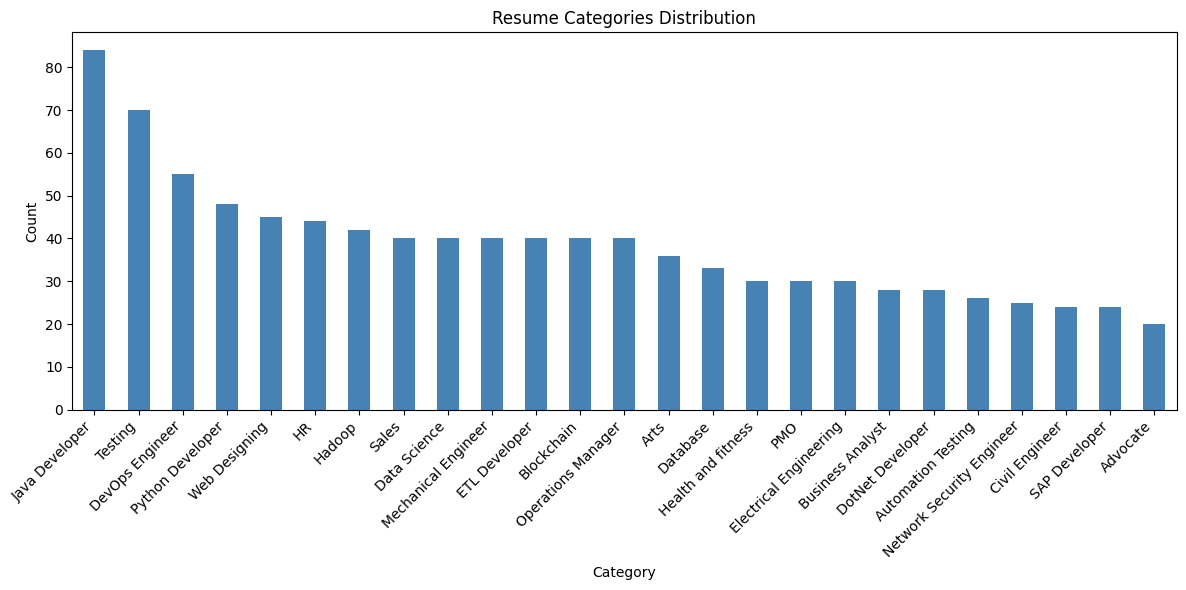

Average resume length (chars): 3160.0
Min: 142
Max: 14816


In [8]:
plt.figure(figsize=(12, 6))
resume_df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Resume Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

resume_df['resume_length'] = resume_df['Resume'].apply(len)
print("Average resume length (chars):", resume_df['resume_length'].mean().round(0))
print("Min:", resume_df['resume_length'].min())
print("Max:", resume_df['resume_length'].max())

In [9]:
import re
import string

def clean_text(text):
    # lowercase
    text = text.lower()
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

resume_df['clean_resume'] = resume_df['Resume'].apply(clean_text)
jd_df['clean_jd'] = jd_df['full_jd'].apply(clean_text)

print("=== CLEANED RESUME (first 300 chars) ===")
print(resume_df['clean_resume'][0][:300])

print("\n=== CLEANED JD (first 300 chars) ===")
print(jd_df['clean_jd'][0][:300])

=== CLEANED RESUME (first 300 chars) ===
skills programming languages python pandas numpy scipy scikitlearn matplotlib sql java javascriptjquery machine learning regression svm nave bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality reduct

=== CLEANED JD (first 300 chars) ===
procurement manager promote diversity and inclusion in the supply chain manage supplier diversity programs and assess supplier performance supplier diversity programs diversity and inclusion initiatives supplier assessment and certification data collection and reporting vendor outreach and engagemen


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def match_resume_tfidf(resume_text, jd_text):
    corpus = [resume_text, jd_text]
    
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1,2))
    tfidf_matrix = vectorizer.fit_transform(corpus)
    
    score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    return round(score * 100, 2)

sample_resume = resume_df['clean_resume'][0]  
sample_jd = jd_df['clean_jd'][0]            

score = match_resume_tfidf(sample_resume, sample_jd)
print(f"Match Score (TF-IDF): {score}%")

ds_jd = jd_df[jd_df['Job Title'].str.contains('Data', case=False, na=False)].iloc[0]
ds_score = match_resume_tfidf(sample_resume, ds_jd['clean_jd'])
print(f"Match Score with Data JD (TF-IDF): {ds_score}%")
print(f"JD Title: {ds_jd['Job Title']}")

Match Score (TF-IDF): 1.77%
Match Score with Data JD (TF-IDF): 11.62%
JD Title: Data Analyst


In [11]:
SKILLS = [
    # Programming Languages
    'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'r', 'scala',
    'golang', 'ruby', 'php', 'swift', 'kotlin', 'matlab', 'bash', 'perl',

    # Data Science & ML
    'machine learning', 'deep learning', 'nlp', 'natural language processing',
    'computer vision', 'reinforcement learning', 'transfer learning',
    'supervised learning', 'unsupervised learning', 'neural network',
    'random forest', 'xgboost', 'gradient boosting', 'svm', 'regression',
    'classification', 'clustering', 'pca', 'feature engineering',
    'feature selection', 'model evaluation', 'hyperparameter tuning',
    'time series', 'anomaly detection', 'recommendation system',

    # ML Frameworks & Libraries
    'tensorflow', 'keras', 'pytorch', 'scikit-learn', 'pandas', 'numpy',
    'scipy', 'matplotlib', 'seaborn', 'plotly', 'opencv', 'nltk', 'spacy',
    'huggingface', 'transformers', 'langchain', 'fastai',

    # Data & Databases
    'sql', 'mysql', 'postgresql', 'mongodb', 'sqlite', 'oracle', 'redis',
    'cassandra', 'elasticsearch', 'hbase', 'dynamodb',
    'data analysis', 'data visualization', 'data wrangling', 'data cleaning',
    'exploratory data analysis', 'eda', 'etl', 'data pipeline',
    'statistics', 'probability', 'linear algebra',

    # BI & Analytics Tools
    'tableau', 'power bi', 'excel', 'google analytics', 'looker', 'qlik',
    'jupyter', 'google colab',

    # Big Data
    'spark', 'hadoop', 'hive', 'kafka', 'airflow', 'databricks', 'snowflake',

    # Web & Backend
    'react', 'node', 'nodejs', 'html', 'css', 'flask', 'django', 'fastapi',
    'rest api', 'graphql', 'spring', 'express',

    # Cloud & DevOps
    'aws', 'azure', 'google cloud', 'gcp', 'docker', 'kubernetes',
    'ci/cd', 'jenkins', 'terraform', 'linux', 'git', 'github', 'mlops',

    # LLM & GenAI
    'llm', 'gpt', 'bert', 'distilbert', 'prompt engineering', 'fine tuning',
    'rag', 'vector database', 'embeddings', 'openai', 'claude', 'langchain',

    # Soft Skills
    'communication', 'teamwork', 'leadership', 'problem solving',
    'critical thinking', 'project management', 'agile', 'scrum',
    'collaboration', 'presentation', 'research'
]

def extract_skills(text):
    text_lower = text.lower()
    found = [skill for skill in SKILLS if skill in text_lower]
    return list(set(found))

resume_skills = extract_skills(resume_df['clean_resume'][0])
jd_skills = extract_skills(ds_jd['clean_jd'])

print("Resume skills:", resume_skills)
print("\nJD skills:", jd_skills)

matched = set(resume_skills) & set(jd_skills)
missing = set(jd_skills) - set(resume_skills)

print(f"\nMatched skills ({len(matched)}):", matched)
print(f"Missing skills ({len(missing)}):", missing)

Resume skills: ['time series', 'machine learning', 'pandas', 'deep learning', 'matplotlib', 'nltk', 'elasticsearch', 'kafka', 'flask', 'python', 'r', 'spacy', 'computer vision', 'tableau', 'svm', 'research', 'hbase', 'html', 'pca', 'css', 'classification', 'numpy', 'docker', 'sql', 'nodejs', 'natural language processing', 'random forest', 'git', 'node', 'mysql', 'cassandra', 'java', 'javascript', 'regression', 'express', 'plotly', 'scipy']

JD skills: ['r', 'power bi', 'data analysis', 'sql', 'data visualization', 'tableau']

Matched skills (3): {'sql', 'r', 'tableau'}
Missing skills (3): {'data analysis', 'power bi', 'data visualization'}


In [15]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

def match_resume_bert(resume_text, jd_text):
    
    embeddings = model.encode([resume_text, jd_text])
    
    score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    return round(score * 100, 2)

sample_resume = resume_df['clean_resume'][0]

bert_score_irrelevant = match_resume_bert(sample_resume, jd_df['clean_jd'][0])
print(f"\nBERT Score - Procurement JD: {bert_score_irrelevant}%")

bert_score_relevant = match_resume_bert(sample_resume, ds_jd['clean_jd'])
print(f"BERT Score - Data Analyst JD: {bert_score_relevant}%")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!

BERT Score - Procurement JD: 20.790000915527344%
BERT Score - Data Analyst JD: 37.72999954223633%


In [16]:
def match_resume(resume_text, jd_text):
    tfidf_score = match_resume_tfidf(resume_text, jd_text)
    bert_score = match_resume_bert(resume_text, jd_text)
    
    final_score = round((0.3 * tfidf_score) + (0.7 * bert_score), 2)
    
    resume_skills = extract_skills(resume_text)
    jd_skills = extract_skills(jd_text)
    matched = set(resume_skills) & set(jd_skills)
    missing = set(jd_skills) - set(resume_skills)
    
    return {
        'tfidf_score': tfidf_score,
        'bert_score': bert_score,
        'final_score': final_score,
        'matched_skills': list(matched),
        'missing_skills': list(missing),
        'resume_skills': resume_skills
    }

result = match_resume(sample_resume, ds_jd['clean_jd'])

print("=== MATCH REPORT ===")
print(f"TF-IDF Score:  {result['tfidf_score']}%")
print(f"BERT Score:    {result['bert_score']}%")
print(f"Final Score:   {result['final_score']}%")
print(f"\nMatched Skills: {result['matched_skills']}")
print(f"Missing Skills: {result['missing_skills']}")

=== MATCH REPORT ===
TF-IDF Score:  11.62%
BERT Score:    37.72999954223633%
Final Score:   29.9%

Matched Skills: ['sql', 'r', 'tableau']
Missing Skills: ['data analysis', 'power bi', 'data visualization']


In [17]:
print(jd_df['Job Title'].unique()[:50])

['Procurement Manager' 'Architectural Designer' 'Art Teacher'
 'Environmental Consultant' 'Event Planner' 'Architect' 'Family Lawyer'
 'Account Manager' 'Business Development Manager' 'Network Engineer'
 'IT Manager' 'HR Coordinator' 'Human Resources Manager'
 'Customer Support Specialist' 'Content Writer' 'Network Administrator'
 'Chemical Analyst' 'Psychologist' 'Software Engineer'
 'Physician Assistant' 'Financial Advisor' 'Litigation Attorney'
 'Front-End Developer' 'IT Support Specialist' 'Paralegal' 'Legal Counsel'
 'UX/UI Designer' 'Social Media Coordinator' 'Tax Consultant'
 'Electrical Designer' 'UX Researcher' 'Systems Administrator'
 'Customer Service Manager' 'UI Developer' 'Sales Associate'
 'Mechanical Engineer' 'HR Manager' 'Environmental Engineer'
 'Office Manager' 'Marketing Analyst' 'Network Analyst' 'Civil Engineer'
 'Digital Marketing Specialist' 'Landscape Architect' 'Legal Secretary'
 'Financial Analyst' 'Veterinarian' 'Software Tester'
 'Project Coordinator' 'QA 

In [18]:
test_jds = [
    jd_df[jd_df['Job Title'].str.contains('Software Engineer', case=False, na=False)].iloc[0],
    jd_df[jd_df['Job Title'].str.contains('Data', case=False, na=False)].iloc[0],
    jd_df[jd_df['Job Title'].str.contains('Marketing Analyst', case=False, na=False)].iloc[0],
    jd_df[jd_df['Job Title'].str.contains('Procurement', case=False, na=False)].iloc[0],
    jd_df[jd_df['Job Title'].str.contains('Financial Analyst', case=False, na=False)].iloc[0],
]

print("=== RANKING RESUME AGAINST MULTIPLE JDs ===\n")
results = []
for jd in test_jds:
    r = match_resume(sample_resume, jd['clean_jd'])
    results.append({
        'Job Title': jd['Job Title'],
        'Final Score': r['final_score'],
        'Matched Skills': len(r['matched_skills']),
        'Missing Skills': len(r['missing_skills'])
    })

results_df = pd.DataFrame(results).sort_values('Final Score', ascending=False)
print(results_df.to_string(index=False))

=== RANKING RESUME AGAINST MULTIPLE JDs ===

          Job Title  Final Score  Matched Skills  Missing Skills
       Data Analyst        29.90               3               3
  Marketing Analyst        27.21               2               1
  Software Engineer        26.15               7               4
  Financial Analyst        18.15               2               1
Procurement Manager        15.08               1               1


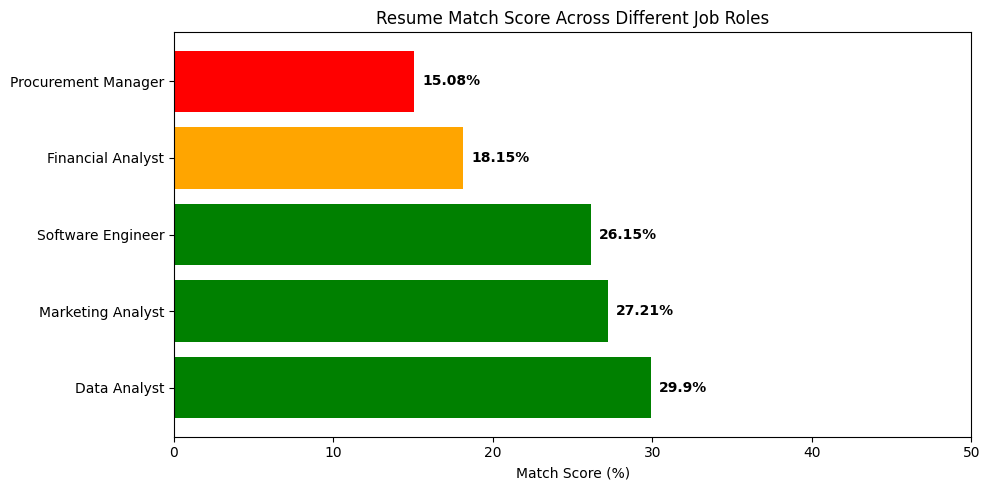

In [19]:
plt.figure(figsize=(10, 5))
colors = ['green' if s > 25 else 'orange' if s > 18 else 'red' 
          for s in results_df['Final Score']]

plt.barh(results_df['Job Title'], results_df['Final Score'], color=colors)
plt.xlabel('Match Score (%)')
plt.title('Resume Match Score Across Different Job Roles')
plt.xlim(0, 50)

for i, (score, title) in enumerate(zip(results_df['Final Score'], results_df['Job Title'])):
    plt.text(score + 0.5, i, f'{score}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()